# HW 3: STFT, Features, and Regression (15 points)

For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

Read in the following files from your "audio" folder.
- /audio/country.00000.wav
- /audio/hiphop.00000.wav
    
Ensure that amplitudes are normalized to between -1 and 1. 

In [6]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal
from numpy import fft
from scipy.io.wavfile import read
from IPython.display import Audio
from librosa import frames_to_time
from librosa.feature import zero_crossing_rate, spectral_centroid


In [9]:
fs, x = read('../audio/country.00000.wav')
fs1, x1 = read('../audio/hiphop.00000.wav')
x_norm = x/np.max(abs(x))
x1_norm = x1/np.max(abs(x1))

In [37]:
import math
def NextPowerOfTwo(number):
    return 2**(math.ceil(np.log2(number)))

## Part 1: STFT parameters and visualization (6 points)

#### Write your own STFT (3 points)

Write your own STFT function that will output a 2D matrix with shape (num_frames, num_bins), where each row contains the DFT of a single frame.

* Use a hop size equal to half the frame size (i.e., hop_size = frame_size // 2) so that frames overlap by 50%, and you should apply a hanning window to each frame (you may use `np.hanning()` for this.)

* The user should be able to vary the size of the frame (leave hop_size fixed at 50%).

*Note: You should use the built in numpy FFT function (instead of your DFT). This means you will have to work in powers of 2!*

In [38]:
# your code here
def my_stft(audio_input, frame_size, sampling_rate = 44100):
    
    # Define frame_length (should be power of two based on input frame_size)
    frame_length = NextPowerOfTwo(frame_size)

    # Define hop size is half the frame size
    hop_length = frame_length // 2

    # Define number of frames (m) we can extract with 50% overlap based on the total length of our signal
    # If the signal does not fit an integer number of frames, truncate
    n_mbins = int(audio_input.size / hop_length) - 1

    # Define total number of frequency bins
    n_kbins = frame_length/2

    # Pre-allocate matrix for STFT. Remember it should be structured as [time_frames, frequency_bins]
    stft_matrix = np. arrays((np.zreos(n_mbins),np.zeros(n_kbins)))

    # Define window
    window = np.hanning(frame_length)

    # Iterate through signal by frame
    for m in range(n_mbins+1):
        i = m * hop_length
        frame = audio_input[i:i+frame_length]
        frame_win = frame * window
        stft_matrix[m][1] = fft(frame_win)
        # index into the frame, apply window, apply fft over the frame, store in matrix
        stft_matrix = stft_matrix.append(stft_matrix[m][1])

    return stft_matrix


In [39]:
signal_length = 500
frame_length = 100
hop_length = 50
mb = int(signal_length / hop_length) - 1
nk = frame_length // 2
stft_matrix = np.array((np.zeros(mb), np.zeros(nk)))
stft_matrix

/var/folders/88/n40k4jj52mlcqk5ftw8mhlsm0000gn/T/ipykernel_48228/896895219.py:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  stft_matrix = np.array((np.zeros(mb), np.zeros(nk)))


array([array([0., 0., 0., 0., 0., 0., 0., 0., 0.]),
       array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
              0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
              0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])   ],
      dtype=object)

#### Apply your STFT function

Apply your STFT function to the audio files listed above (country and hiphop)

In [40]:
# your code here

#### Write your own spectrogram function (3 points)

Write your own spectrogram function (using `plt.pcolormesh()`) called `plot_spectrogram()` that takes the complex-valued STFT output from your above function, and the sampling rate, and plots a magnitude spectrogram in decibels.

The axes should be properly labeled (time on x-axis, Frequency on y-axis).

*Note: audio processing workflows and dataframe logic in general in Python commonly use rows = time. However, several plotting functions like pcolormesh() annoyingly expect rows = frequency and columns = time. Therefore, we simply add a step to 'transpose' our 2d array or matrix in our code below.*


In [41]:
# your code here
def plot_spectrogram(stft_matrix, frame_size, sampling_rate):

    # Take magnitude and convert to decibels
    magnitude = np.abs(stft_matrix).T  # Transpose so rows = frequencies
    magnitude_db = 20 * np.log10(magnitude + 1e-6)  # avoid log(0)

    # Time and frequency axes
    num_frames =  # total number of frames
    hop_size =    # recall it was 50% of the frame size
    duration =    # find duration
    
    # Make a time axis by taking the total duration and dividing the timeline according to the number of frames:
    time_axis = 
    # Ditto for frequency axis according to the number of bins
    freq_axis = 

    # Plot only up to Nyquist frequency by indexing your magnitude vector
    

SyntaxError: invalid syntax (1782587421.py, line 9)

Plot the spectrogram of the country and hiphop audio files

## Part 2: Feature Extraction (4 points)

We will perform feature extraction and compare the two audio files above.

Extract the following features for each file (you may use librosa functions):
- RMSE
- Spectral Centroid
- Spectral Flux
- ZCR

For each feature:
- graph the results of each feature
- briefly describe what the feature might tell us perceptually
- briefly describe whether or not this might be a useful feature for classification (based on the graphs)

1 point for each correct feature calculation and associated explanation/reasoning

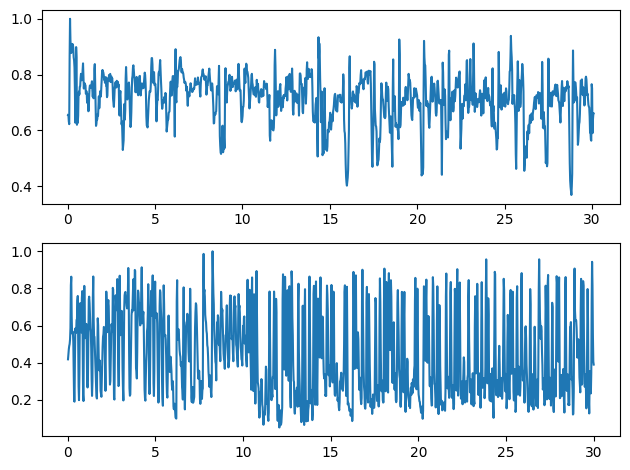

In [16]:
frame_length = 1024
hop_length = 512
# RMSE for hiphop
energy = np.array([sum(abs(x_norm[i:i+frame_length])) for i in range(0, len(x_norm), hop_length)])
rmse_hiphop = np.array([])
for i in range(0,len(x_norm),hop_length):
    rms_i_hiphop = np.sqrt(np.mean(abs(x_norm[i:i+frame_length]**2)))
    rmse_hiphop = np.append(rmse_hiphop,rms_i_hiphop)
# RMSE for country
energy1 = np.array([sum(abs(x1_norm[i:i+frame_length])) for i in range(0, len(x1_norm), hop_length)])
rmse_country = np.array([])
for i in range(0,len(x1_norm),hop_length):
    rms_i_country = np.sqrt(np.mean(abs(x1_norm[i:i+frame_length]**2)))
    rmse_country = np.append(rmse_country,rms_i_country)
# plotting
frames = range(1,len(energy)+1)
t = frames_to_time(frames, sr=fs, hop_length = hop_length)
frames1 = range(1,len(energy1)+1)
t1 = frames_to_time(frames1, sr=fs1, hop_length = hop_length)

plt.subplot(2,1,1)
plt.plot(t,rmse_hiphop/rmse_hiphop.max())
plt.subplot(2,1,2)
plt.plot(t1,rmse_country/rmse_country.max())
plt.tight_layout()

Your RMSE explantion here!

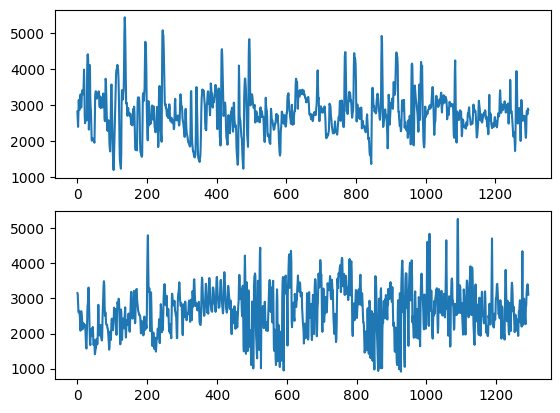

In [19]:
# Spectral Centroid for hiphop
hip_hop_sc = spectral_centroid(y=x_norm.astype(float), sr=fs)
# Spectral Centroid for country
country_sc = spectral_centroid(y=x1_norm.astype(float), sr=fs1)
# plotting
plt.subplot(2,1,1)
plt.plot(hip_hop_sc[0])
plt.subplot(2,1,2)
plt.plot(country_sc[0])

Your centroid explanation here!

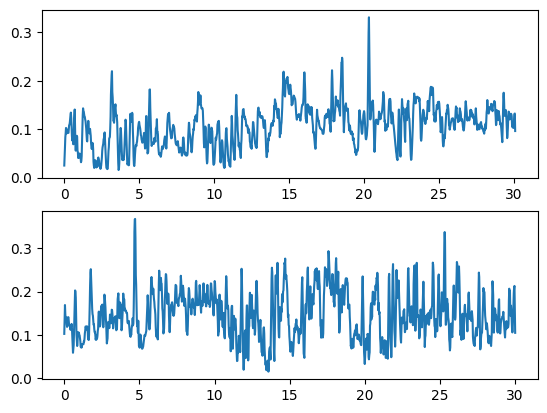

In [ ]:
# spectral flux for hiphop
hip_hop_zcr = zero_crossing_rate(x_norm.astype(float), hop_length=hop_length)
# spectral flux for country
country_zcr = zero_crossing_rate(x1_norm.astype(float), hop_length=hop_length)
# plotting


Your spectral flux explanation here!

In [ ]:
# ZCR for hiphop
hip_hop_zcr = zero_crossing_rate(x_norm.astype(float), hop_length=hop_length)
# ZCR for country
country_zcr = zero_crossing_rate(x1_norm.astype(float), hop_length=hop_length)
# plotting
ax1 = np.linspace(0,len(x_norm)/fs,len(hip_hop_zcr[0]))
ax2 = np.linspace(0,len(x1_norm)/fs1,len(country_zcr[0]))

plt.subplot(2,1,1)
plt.plot(ax1,hip_hop_zcr[0])
plt.subplot(2,1,2)
plt.plot(ax2,country_zcr[0])

Your ZCR explanation here!

## Part 3: Binomial Logistic Regression (5 points)

Like in activity 7, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' this time to classify hiphop vs country music.

### Explore the data and select your features (3 points)

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You must at a minimum create 1 bar graph and 1 box plot in addition to computing the correlation between the features you select.

Construct your Pandas dataframe for your chosen features. Remember you may want to do some scaling and normalization.

### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. Use 30% test size.

### Train the Model and Evaluate (2 points)

Train the model using logistic regression.

Calculate the confusion matrix (and view as a data frame). Calculate the accuracy, precision, recall, and F1 scores.

Explain what the confusion matrix and accuracy tell us about your model.

Your model interpretation here!

GenAI Usage Statement:

- Tool used and date of access
- The input (prompt) you provided
- A copy of the output
- A description of how you used or edited the AI-generated content